In [1]:
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader,TensorDataset
import matplotlib.pyplot as plt

In [2]:
df=pd.read_csv("powerplant_data.csv")

In [3]:
df.head(3)

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76


In [4]:
df=df.rename(
    {"AT":"Temperature",
     "V":"Velocity",
     "AP":"Pressure",
     "RH":"Humidity",
     "PE":"Produced_Energy"},axis=1
     )

In [5]:
df.head(2)

,Temperature,Velocity,Pressure,Humidity,Produced_Energy
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Temperature      9568 non-null   float64
 1   Velocity         9568 non-null   float64
 2   Pressure         9568 non-null   float64
 3   Humidity         9568 non-null   float64
 4   Produced_Energy  9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [7]:
df.isnull().sum()

Temperature        0
Velocity           0
Pressure           0
Humidity           0
Produced_Energy    0
dtype: int64

In [8]:
X=df.drop("Produced_Energy",axis=1)
y=df["Produced_Energy"]

## Train-Test split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

## Scaling the data

In [10]:
scaler=StandardScaler()

X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.transform(X_test)

In [11]:
type(X_train_scaled)

numpy.ndarray

In [12]:
type(y_train)

pandas.core.series.Series

In [13]:
y_train.shape

(7654,)

## Pytorch Tensor

In [14]:
X_train_tensor=torch.tensor(X_train_scaled,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)

X_test_tensor=torch.tensor(X_test_scaled,dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)

# Since y_train and y_test are not scaled and are currently pandas series, and X_train_scaled, X_test_scaled are numpy array, there is a type difference hence we use .values to extract values.
# .view is used to change dimensions, currently the dimension is (n,) but pytorch would require (n,1), where -1 is the total rows, 1 is the number of cols

## Tensor Dataset and Data Loader

In [15]:
train_dataset=TensorDataset(X_train_tensor,y_train_tensor)

test_dataset=TensorDataset(X_test_tensor,y_test_tensor)

In [16]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)

test_loader=DataLoader(test_dataset,batch_size=32)

## Deep Learning

### Define the ANN model

In [17]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self).__init__()

        self.model=nn.Sequential(
            # 1st Hidden Layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1)
         
        )   

    def forward(self,x):
        return self.model(x)

In [18]:
model=ANN()

## Loss Function and Optimizer

In [19]:
import torch.optim as optim

criterion=nn.MSELoss()
optimizer=optim.Adam(model.parameters()) #weight and bias

# Training & Validation of the ANN

In [20]:
epochs=100
train_losses=[]
val_losses=[]

best_val_loss=float("inf")

for epoch in range(epochs):
    model.train()
    running_loss=0.0 #total training loss for one epoch

    for xb,yb in train_loader: #xb - features of one batch and yb - labels of 1 batch

        optimizer.zero_grad()
        outputs=model(xb) #forward propogation #predicted outputs one one bacth
        loss=criterion(outputs,yb) # loss computation
        loss.backward() #back propagation
        optimizer.step() #param update

        running_loss +=loss.item() #Loss tensor value to python float

    epoch_train_loss=running_loss/len(train_loader)
    train_losses.append(epoch_train_loss)


        #Validation
    model.eval()
    running_val_loss=0.0

    with torch.no_grad(): #no gradient computation
        for xb,yb in test_loader: 
            outputs=model(xb) 
            loss=criterion(outputs,yb) 

            running_val_loss += loss.item() 

    epoch_val_loss=running_val_loss/len(test_loader) #len(test_loader) provide the value of batches
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epoch} ==> train loss={epoch_train_loss:.4f} & val loss={epoch_val_loss:.4f}")

    if epoch_val_loss > best_val_loss:
        best_val_loss=epoch_val_loss

        torch.save(model.state_dict(),"best_model.pt")
        

epoch 1/0 ==> train loss=205660.9458 & val loss=203468.8333
epoch 2/1 ==> train loss=195855.9040 & val loss=184078.5362
epoch 3/2 ==> train loss=165161.1632 & val loss=143353.4734
epoch 4/3 ==> train loss=121287.8838 & val loss=100672.4783
epoch 5/4 ==> train loss=86039.1694 & val loss=73058.9833
epoch 6/5 ==> train loss=63358.7762 & val loss=53139.8428
epoch 7/6 ==> train loss=44552.1313 & val loss=35189.9555
epoch 8/7 ==> train loss=27964.1660 & val loss=20386.9421
epoch 9/8 ==> train loss=15247.0576 & val loss=10119.6374
epoch 10/9 ==> train loss=7637.9283 & val loss=5514.5026
epoch 11/10 ==> train loss=4955.6135 & val loss=4203.2868
epoch 12/11 ==> train loss=3994.7479 & val loss=3526.9231
epoch 13/12 ==> train loss=3396.7054 & val loss=3026.0223
epoch 14/13 ==> train loss=2929.4468 & val loss=2623.8528
epoch 15/14 ==> train loss=2554.0149 & val loss=2280.7904
epoch 16/15 ==> train loss=2227.5563 & val loss=1989.2221
epoch 17/16 ==> train loss=1940.9265 & val loss=1732.4885
epoch 1

In [ ]:
# saving to the current directory
from pathlib import Path

model_path = Path.cwd() / "best_model.pt"
torch.save(model.state_dict(), model_path)
print(f"Saved to: {model_path}")

Saved to: /Users/aksha/Desktop/Apna College AI:ML/Deep Learning 3/best_model.pt


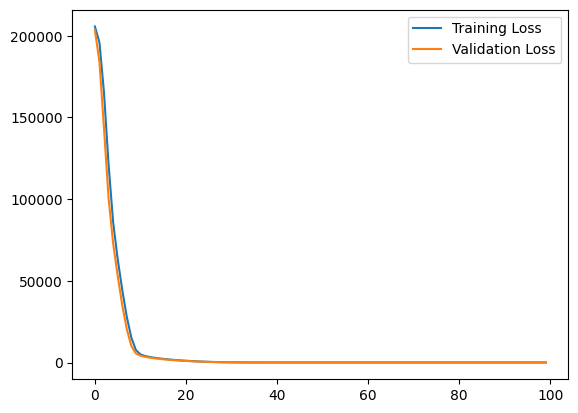

In [22]:
dataset = pd.DataFrame({"Training Loss":train_losses,
                        "Validation Loss":val_losses})

plt.plot(dataset["Training Loss"],label="Training Loss")
plt.plot(dataset["Validation Loss"],label="Validation Loss")

plt.legend()

## Loading best model

In [23]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

## Evaluation

In [29]:
model.eval()

with torch.no_grad():
    train_preds=model(X_train_tensor)
    test_preds=model(X_test_tensor)

    train_mse_loss=criterion(train_preds,y_train_tensor)
    test_mse_loss=criterion(test_preds,y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())



Training MSE: 20.620283126831055
Testing MSE: 19.147836685180664


In [25]:
from sklearn.metrics import r2_score

print("r2 score=", r2_score(y_test,test_preds))

r2 score= 0.9330832457246339


## Actual vs Predicted Values

In [27]:
actual_values=pd.DataFrame(y_test.values,columns=["Actual Values"])
predicted_values=pd.DataFrame(test_preds.numpy(),columns=["Predicted Values"])

pd.concat([actual_values,predicted_values],axis=1)

,Actual Values,Predicted Values
0,433.27,435.994415
1,438.16,437.320496
2,458.42,461.937897
3,480.82,476.630463
4,441.41,436.152405
...,...,...
1909,456.70,451.762878
1910,438.04,432.223114
1911,467.80,468.069031
1912,437.14,431.618378
